In [ ]:
#### install dependencies
%pip install segment-geospatial
!pip install geojson
!pip install ultralytics

!pip install 'git+https://github.com/facebookresearch/segment-anything.git'
from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.98 🚀 Python-3.10.12 torch-2.4.0+cpu CPU (Intel Xeon 2.00GHz)
Setup complete ✅ (96 CPUs, 334.6 GB RAM, 20.4/225.3 GB disk)


In [ ]:
!pip install leafmap

import leafmap
from samgeo import tms_to_geotiff
from samgeo import SamGeo
import os
from samgeo import SamGeo, tms_to_geotiff, get_basemaps
import rasterio
from rasterio.transform import Affine
from pyproj import Transformer
import numpy as np
import geojson
from PIL import Image
from ultralytics import YOLO
from IPython.display import display, Image
import sys
import cv2
import matplotlib.pyplot as plt

# Set the device for GPU acceleration
device = "cuda"

ModuleNotFoundError: No module named 'samgeo'

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
m = leafmap.Map(center=[17.492837, 78.565416], zoom=18, height="800px")
m.add_basemap("SATELLITE")
m

Map(center=[17.492837, 78.565416], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title',…

In [ ]:
bbox = m.user_roi_bounds()
if bbox is None:
    bbox = [-51.2565, -22.1777, -51.2512, -22.175]

In [ ]:
image = "Image.tif"
tms_to_geotiff(output=image, bbox=bbox, zoom=19, source="Satellite", overwrite=True)

Downloaded image 01/16
Downloaded image 02/16
Downloaded image 03/16
Downloaded image 04/16
Downloaded image 05/16
Downloaded image 06/16
Downloaded image 07/16
Downloaded image 08/16
Downloaded image 09/16
Downloaded image 10/16
Downloaded image 11/16
Downloaded image 12/16
Downloaded image 13/16
Downloaded image 14/16
Downloaded image 15/16
Downloaded image 16/16
Saving GeoTIFF. Please wait...
Image saved to Image.tif


In [ ]:
# image = '/path/to/your/own/image.tif'

In [ ]:
m.layers[-1].visible = False
m.add_raster(image, layer_name="Image")
m

Map(bottom=30242058.0, center=[17.4934, 78.56530000000001], controls=(ZoomControl(options=['position', 'zoom_i…

## Segment Anything Model

In [ ]:
sam = SamGeo(
    model_type="vit_h",
    automatic=False,
    sam_kwargs=None,
)

Model checkpoint for vit_h not found.


Downloading...
From: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
To: /root/.cache/torch/hub/checkpoints/sam_vit_h_4b8939.pth
100%|██████████| 2.56G/2.56G [00:22<00:00, 112MB/s]


In [ ]:
sam.set_image(image)

In [ ]:
m

Map(bottom=30242058.0, center=[17.4934, 78.56530000000001], controls=(ZoomControl(options=['position', 'zoom_i…

## YOLOv8 for bounding boxes


In [ ]:
model = YOLO(r"/content/drive/MyDrive/best (1).pt")
results = model(image)  # return a list of Results objects
img = results[0].plot(font_size=2, pil=True)
print(results)
cv2.imwrite("/content/1.jpg", img)
print(results)
map={0:[], 51:[]}
for result in results:
    boxes = result.boxes.xyxy.tolist()
    classes = result.boxes.cls.tolist()
    names = result.names
    confidences = result.boxes.conf.tolist()

print(boxes)
print(classes)
print(names)
for i in range(0,len(boxes)):
  cl=int(classes[i])
  map[cl].append(boxes[i])

print(map)


image 1/1 /content/Image.tif: 512x640 164 Built-ups, 40.2ms
Speed: 22.3ms preprocess, 40.2ms inference, 672.5ms postprocess per image at shape (1, 3, 512, 640)


100%|██████████| 755k/755k [00:00<00:00, 81.1MB/s]


[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'Built-up'}
obb: None
orig_img: array([[[ 61,  56,  55],
        [ 60,  55,  52],
        [ 73,  68,  65],
        ...,
        [198, 189, 192],
        [180, 171, 174],
        [134, 123, 126]],

       [[ 91,  88,  84],
        [ 94,  88,  83],
        [ 91,  85,  78],
        ...,
        [215, 204, 207],
        [165, 154, 157],
        [107,  96,  98]],

       [[112, 109, 104],
        [115, 109, 102],
        [ 96,  89,  80],
        ...,
        [205, 194, 197],
        [144, 133, 135],
        [115, 104, 106]],

       ...,

       [[114, 110, 122],
        [110, 103, 116],
        [119, 112, 125],
        ...,
        [ 77,  60,  51],
        [ 81,  62,  55],
        [ 63,  44,  37]],

       [[114, 110, 122],
        [111, 104, 117],
        [117, 110, 123],
        ...,
        [ 59,  43,  36],
        [ 64,  45,  40],
        [ 

Don't run the next 3 blocks, it's for visualization only.

In [ ]:
#### define functions for displaying the masks and the bounding boxes
# color_map_mask={0:[255/255, 0/255, 0/255, 0.6],1:[0/255, 255/255, 0/255, 0.6],2:[255/255, 255/255, 0/255, 0.6],3:[0/255, 0/255, 255/255, 0.6]}
def show_mask(mask, ax,i, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([0/255, 255/255, 0/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
# {0: 'Building', 1: 'Vegetation', 2: 'Metro Station', 3: 'Railway Station', 4: 'Agriculture and Grassland', 5: 'Bare Ground/Vacant Plots', 6: 'Water Bodies', 7: 'Planes', 8: 'Sadium', 9: 'Airport Hanger'}
# def show_points(coords, labels, ax, marker_size=375):
#     pos_points = coords[labels==1]
#     neg_points = coords[labels==0]
#     ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
#     ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
# color_map_box={0: 'red', 1: 'green', 2: 'light blue', 3: 'pink', 4: 'white', 5: 'green', 6: 'blue', 7: 'orange', 8: 'dark blue', 9: 'grey'}
# color_map_box={0:[255/255, 0/255, 0/255, 1.0],1:[0/255, 255/255, 0/255, 1.0],2:[255/255, 255/255, 0/255, 1.0],3:[0/255, 0/255, 255/255, 1.0]}
def show_box(box, ax,i):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor=np.array([0/255, 255/255, 0/255, 0.6]), facecolor=(0,0,0,0), lw=2))

In [ ]:
#### SAM for this, again prolly not required
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
import cv2
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor
image = cv2.cvtColor(cv2.imread("Image.tif"), cv2.COLOR_BGR2RGB)
# SamAutomaticMaskGenerator, SamPredictor
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
device="cpu"
sam.to(device=device)
predictor = SamPredictor(sam)
predictor.set_image(image)

--2024-08-27 00:59:32--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.35.7.128, 13.35.7.38, 13.35.7.82, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.35.7.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G  28.7MB/s    in 53s     

2024-08-27 01:00:25 (46.4 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



In [ ]:
#### for displaying the mask and bb, prolly not necessary though

plt.figure(figsize=(10, 10))
image = Image.open('Image.tif')
image = np.array(image) # Convert to a NumPy array

plt.figure(figsize=(10, 10))
plt.imshow(image)
i = 0
# for i in range(0,4):
input_box=map[i]
perclass_masks=[]
for bb in input_box:
 masks, _, _ = predictor.predict(
  point_coords=None,
  point_labels=None,
  box=np.array([bb]), # Convert bb to a NumPy array and add a dimension
  multimask_output=False,
 )
 perclass_masks.append(masks)
# for bb in input_box:
#   show_box(bb, plt.gca(),i)
for mask in perclass_masks:
  show_mask(mask, plt.gca(), i)

## Convert the bounding boxes to a vector file as box prompts


In [ ]:
# url = "https://opengeos.github.io/data/sam/tree_boxes.geojson"
# geojson = "/content/polygon (5).geojson"
# leafmap.download_file(url, geojson)
!pip install pyproj

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 26.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
from pyproj import Transformer

def pixel_to_geo(x_pixel, y_pixel, image_width, image_height, bbox):
    min_lon, min_lat, max_lon, max_lat = bbox

    # Calculate normalized coordinates (0 to 1)
    norm_x = x_pixel / image_width
    norm_y = y_pixel / image_height

    # Interpolate to geographic coordinates
    lon = min_lon + (max_lon - min_lon) * norm_x
    lat = min_lat + (max_lat - min_lat) * (1 - norm_y)  # y-axis is flipped

    return lon, lat

# Example usage
file_path = 'Image.tif'

# Open the raster file
with rasterio.open(file_path) as src:
    # Get the width and height of the image
    width = src.width
    height = src.height

main_inputbox = []
for box in boxes:
    x0 = box[0]
    y0 = box[1]
    x1 = box[2]
    y1 = box[3]
    lon0, lat0 = pixel_to_geo(x0, y0, width, height, bbox)
    lon1, lat1 = pixel_to_geo(x1, y1, width, height, bbox)
    new_coord = [lon0, lat0, lon1, lat1]
    main_inputbox.append(new_coord)
print(main_inputbox)


NameError: name 'rasterio' is not defined

In [ ]:
!pip install geojson


In [ ]:
import geojson

def bbox_to_polygon(min_lon, min_lat, max_lon, max_lat):
    return [
        [
            [min_lon, min_lat],
            [max_lon, min_lat],
            [max_lon, max_lat],
            [min_lon, max_lat],
            [min_lon, min_lat]  # Close the polygon
        ]
    ]

# Convert bounding boxes to GeoJSON features
features = []
for bbox in main_inputbox:
    min_lon, min_lat, max_lon, max_lat = bbox
    polygon_coords = bbox_to_polygon(min_lon, min_lat, max_lon, max_lat)
    feature = {
        "type": "Feature",
        "properties": {},
        "geometry": {
            "type": "Polygon",
            "coordinates": polygon_coords
        }
    }
    # print(min_lon, min_lat, max_lon, max_lat)
    # print(main_inputbox)
    features.append(feature)
    # print(feature)

# Create the FeatureCollection
geojson_data = {
    "type": "FeatureCollection",
    "crs": {
        "type": "name",
        "properties": {
            "name": "urn:ogc:def:crs:OGC:1.3:CRS84"
        }
    },
    "features": features
}
# print(features)
# Print the GeoJSON data
with open("geojson.geojson", "w") as f:
  geojson.dump(geojson_data, f)
print(geojson.dumps(geojson_data, indent=2))

NameError: name 'main_inputbox' is not defined

Display the vector data on the map.

In [ ]:
m = leafmap.Map()
m.add_raster("Image.tif", layer_name="image")
style = {
    "color": "#ffff00",
    "weight": 2,
    "fillColor": "#7c4185",
    "fillOpacity": 0,
}
m.add_vector("/content/geojson.geojson", style=style, zoom_to_layer=True, layer_name="Bounding boxes")
m

NameError: name 'leafmap' is not defined

In [ ]:
sam.predict(boxes="/content/geojson.geojson", point_crs="EPSG:4326", output="mask2.tif", dtype="uint8")

NameError: name 'sam' is not defined

In [ ]:
m.add_raster("mask2.tif", cmap="Greens", nodata=0, opacity=0.5, layer_name="Tree masks")
m

NameError: name 'm' is not defined

In [ ]:
mask = "mask2.tif"
vector = "segment.gpkg"
sam.tiff_to_gpkg(mask, vector, simplify_tolerance=None)

In [ ]:
shapefile = "segment.shp"
sam.tiff_to_vector(mask, shapefile)

In [ ]:
%pip install geopandas shapely pyvista

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.1/92.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd

# Load the file (it could be a GeoPackage, shapefile, etc.)
gdf = gpd.read_file('/content/segment (1).gpkg')  # Replace with your actual file path

# Check the current CRS to ensure it's EPSG:3857
print(gdf.crs)

# Convert (reproject) the geometries to EPSG:4326 (WGS84)
gdf_4326 = gdf.to_crs(epsg=4326)

# Check the new CRS to ensure it's converted
print(gdf_4326.crs)

# Optionally, save the converted GeoDataFrame to a new file
gdf_4326.to_file('outputgeojson.geojson', driver='GeoJSON')  # Or any format like .shp, .gpkg



EPSG:3857
EPSG:4326


In [ ]:
%pip install keplergl

In [ ]:
from google.colab import output
output.enable_custom_widget_manager()

Support for third party widgets will remain active for the duration of the session. To disable support:

In [ ]:
from google.colab import output
output.disable_custom_widget_manager()

In [ ]:
%pip install leafmap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 965.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.0/483.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.7/213.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.1/85.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7

In [ ]:
import leafmap.kepler as leafmap
m = leafmap.Map(center=[17.492837, 78.565416], zoom=18, height=600, widescreen=False)
m

Map(config={'version': 'v1', 'config': {'mapState': {'latitude': 17.492837, 'longitude': 78.565416, 'zoom': 18…

In [ ]:
geojson = "/content/outputgeojson (1) (1).geojson"
m.add_geojson(geojson, layer_name="Building footprint")
m

Map(config={'version': 'v1', 'config': {'visState': {'filters': [], 'layers': [], 'interactionConfig': {'toolt…

In [ ]:
###view config
# m.config
m.config={'version': 'v1',
 'config': {'visState': {'filters': [],
   'layers': [{'id': '6a72c5',
     'type': 'geojson',
     'config': {'dataId': 'Building footprint',
      'label': 'Building footprint',
      'color': [18, 147, 154],
      'highlightColor': [252, 242, 26, 255],
      'columns': {'geojson': '_geojson'},
      'isVisible': True,
      'visConfig': {'opacity': 0.8,
       'strokeOpacity': 0.8,
       'thickness': 0.5,
       'strokeColor': [221, 178, 124],
       'colorRange': {'name': 'Global Warming',
        'type': 'sequential',
        'category': 'Uber',
        'colors': ['#5A1846',
         '#900C3F',
         '#C70039',
         '#E3611C',
         '#F1920E',
         '#FFC300']},
       'strokeColorRange': {'name': 'Global Warming',
        'type': 'sequential',
        'category': 'Uber',
        'colors': ['#5A1846',
         '#900C3F',
         '#C70039',
         '#E3611C',
         '#F1920E',
         '#FFC300']},
       'radius': 10,
       'sizeRange': [0, 10],
       'radiusRange': [0, 50],
       'heightRange': [0, 500],
       'elevationScale': 0.1,
       'enableElevationZoomFactor': True,
       'stroked': True,
       'filled': True,
       'enable3d': True,
       'wireframe': False},
      'hidden': False,
      'textLabel': [{'field': None,
        'color': [255, 255, 255],
        'size': 18,
        'offset': [0, 0],
        'anchor': 'start',
        'alignment': 'center'}]},
     'visualChannels': {'colorField': None,
      'colorScale': 'quantile',
      'strokeColorField': None,
      'strokeColorScale': 'quantile',
      'sizeField': None,
      'sizeScale': 'linear',
      'heightField': None,
      'heightScale': 'linear',
      'radiusField': None,
      'radiusScale': 'linear'}}],
   'interactionConfig': {'tooltip': {'fieldsToShow': {'Building footprint': [{'name': 'value',
        'format': None}]},
     'compareMode': False,
     'compareType': 'absolute',
     'enabled': True},
    'brush': {'size': 0.5, 'enabled': False},
    'geocoder': {'enabled': False},
    'coordinate': {'enabled': False}},
   'layerBlending': 'normal',
   'splitMaps': [],
   'animationConfig': {'currentTime': None, 'speed': 1}},
  'mapState': {'bearing': 0,
   'dragRotate': False,
   'latitude': 17.49072770937905,
   'longitude': 78.57217131735484,
   'pitch': 0,
   'zoom': 13.202279827837089,
   'isSplit': False},
  'mapStyle': {'styleType': 'dark',
   'topLayerGroups': {},
   'visibleLayerGroups': {'label': True,
    'road': True,
    'border': False,
    'building': True,
    'water': True,
    'land': True,
    '3d building': False},
   'threeDBuildingColor': [9.665468314072013,
    17.18305478057247,
    31.1442867897876],
   'mapStyles': {}}}}

In [ ]:
def enable_3d(config):
    for layer in config['config']['visState']['layers']:
        if 'visConfig' in layer['config']:
            layer['config']['visConfig']['enable3d'] = True
    return config
    #changing the configuration to account for 3d building from 2d to a uniform height
config = enable_3d(m.config)
m.config = config
print(m.config)





{'version': 'v1', 'config': {'visState': {'filters': [], 'layers': [], 'interactionConfig': {'tooltip': {'fieldsToShow': {}, 'compareMode': False, 'compareType': 'absolute', 'enabled': True}, 'brush': {'size': 0.5, 'enabled': False}, 'geocoder': {'enabled': False}, 'coordinate': {'enabled': False}}, 'layerBlending': 'normal', 'splitMaps': [], 'animationConfig': {'currentTime': None, 'speed': 1}}, 'mapState': {'bearing': 0, 'dragRotate': False, 'latitude': 17.49072770937905, 'longitude': 78.57217131735484, 'pitch': 0, 'zoom': 13.202279827837089, 'isSplit': False}, 'mapStyle': {'styleType': 'dark', 'topLayerGroups': {}, 'visibleLayerGroups': {'label': True, 'road': True, 'border': False, 'building': True, 'water': True, 'land': True, '3d building': False}, 'threeDBuildingColor': [9.665468314072013, 17.18305478057247, 31.1442867897876], 'mapStyles': {}}}}


In [ ]:
###save config
with open('buildings_config.py', 'w') as f:
   f.write('config = {}'.format(m.config))

###load config file
%run buildings_config.py

In [ ]:
m

Map(config={'version': 'v1', 'config': {'visState': {'filters': [], 'layers': [], 'interactionConfig': {'toolt…

In [ ]:
m.config

{'version': 'v1',
 'config': {'visState': {'filters': [],
   'layers': [{'id': '6nxl9b2',
     'type': 'geojson',
     'config': {'dataId': 'Building footprint',
      'label': 'Building footprint',
      'color': [18, 147, 154],
      'highlightColor': [252, 242, 26, 255],
      'columns': {'geojson': '_geojson'},
      'isVisible': True,
      'visConfig': {'opacity': 0.8,
       'strokeOpacity': 0.8,
       'thickness': 0.5,
       'strokeColor': [221, 178, 124],
       'colorRange': {'name': 'Global Warming',
        'type': 'sequential',
        'category': 'Uber',
        'colors': ['#5A1846',
         '#900C3F',
         '#C70039',
         '#E3611C',
         '#F1920E',
         '#FFC300']},
       'strokeColorRange': {'name': 'Global Warming',
        'type': 'sequential',
        'category': 'Uber',
        'colors': ['#5A1846',
         '#900C3F',
         '#C70039',
         '#E3611C',
         '#F1920E',
         '#FFC300']},
       'radius': 10,
       'sizeRange': [0, 10

In [ ]:
m.save_to_html(file_name="geojson_map.html")

Map saved to geojson_map.html!


In [ ]:
!pip install pybdshadow

In [ ]:
import json

# Load the GeoJSON file
with open('/content/outputgeojson (1) (1).geojson', 'r') as f:
    geojson_data = json.load(f)

# Add height property to each feature in the GeoJSON
for feature in geojson_data['features']:
    feature['properties']['height'] = 50.0  # You can set this to the desired height

# Save the modified GeoJSON back to a file
with open('/content/outputgeojson (1) (1).geojson', 'w') as f:
    json.dump(geojson_data, f, indent=4)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
!pip install geopandas

In [ ]:
!pip install keplergl

In [ ]:
!pip install pybdshadow

In [ ]:
import pandas as pd
import geopandas as gpd
from keplergl import KeplerGl
import pybdshadow

# Step 1: Read Building GeoJSON data
buildings = gpd.read_file(r'/content/outputgeojson (1) (1).geojson')
buildings['building_id'] = range(len(buildings))

# Step 2: Calculate shadows using pybdshadow
# Given UTC datetime
date = pd.to_datetime('2024-12-09 09:45:33.959797119')\
    .tz_localize('Asia/Kolkata')\
    .tz_convert('UTC')

# Calculate building shadow for sunlight
shadows = pybdshadow.bdshadow_sunlight(buildings, date)

# Step 3: Convert both buildings and shadows GeoDataFrame to GeoJSON
buildings_geojson = buildings.to_json()
shadows_geojson = shadows.to_json()

# Step 4: Define KeplerGl configuration
config = {
    'version': 'v1',
    'config': {
        'visState': {
            'filters': [],
            'layers': [
                {
                    'id': 'dx2rdu6',
                    'type': 'geojson',
                    'config': {
                        'dataId': 'Building footprint',
                        'label': 'Building footprint',
                        'color': [18, 147, 154],
                        'highlightColor': [252, 242, 26, 255],
                        'columns': {'geojson': '_geojson'},
                        'isVisible': True,
                        'visConfig': {
                            'opacity': 1,
                            'strokeOpacity': 0.8,
                            'thickness': 0.5,
                            'strokeColor': [221, 178, 124],
                            'colorRange': {
                                'name': 'Global Warming',
                                'type': 'sequential',
                                'category': 'Uber',
                                'colors': ['#5A1846', '#900C3F', '#C70039', '#E3611C', '#F1920E', '#FFC300']
                            },
                            'radius': 10,
                            'sizeRange': [0, 10],
                            'radiusRange': [0, 50],
                            'heightRange': [0, 500],
                            'elevationScale': 0.1,
                            'enableElevationZoomFactor': True,
                            'stroked': True,
                            'filled': True,
                            'enable3d': True,
                            'wireframe': False
                        }
                    }
                },
                # Shadow layer config
                {
                    'id': 'shadow_layer',
                    'type': 'geojson',
                    'config': {
                        'dataId': 'Shadows',
                        'label': 'Shadows',
                        'color': [0, 0, 0],
                        'highlightColor': [255, 255, 0, 255],
                        'columns': {'geojson': '_geojson'},
                        'isVisible': True,
                        'visConfig': {
                            'opacity': 0.5,
                            'strokeOpacity': 0.5,
                            'thickness': 0.5,
                            'strokeColor': [0, 0, 0],
                            'colorRange': {
                                'name': 'Sunset',
                                'type': 'sequential',
                                'category': 'Uber',
                                'colors': ['#FFD700', '#FF8C00', '#FF4500', '#FF0000']
                            },
                            'radius': 10,
                            'sizeRange': [0, 10],
                            'radiusRange': [0, 50],
                            'heightRange': [0, 500],
                            'elevationScale': 1,
                            'enableElevationZoomFactor': True,
                            'stroked': True,
                            'filled': True,
                            'enable3d': False,
                            'wireframe': False
                        }
                    }
                }
            ],
            'interactionConfig': {
                'tooltip': {
                    'fieldsToShow': {
                        'Building footprint': [{'name': 'value', 'format': None}],
                        'Shadows': [{'name': 'value', 'format': None}]
                    },
                    'enabled': True
                }
            }
        },
        'mapState': {
            'bearing': 24,
            'dragRotate': True,
            'latitude': 17.492236510884933,
            'longitude': 78.56609127181024,
            'pitch': 50,
            'zoom': 16.53012774940319,
            'isSplit': False
        },
        'mapStyle': {
            'styleType': 'dark',
            'topLayerGroups': {},
            'visibleLayerGroups': {
                'label': True,
                'road': True,
                'border': False,
                'building': True,
                'water': True,
                'land': True,
                '3d building': False
            }
        }
    }
}

# Step 5: Create the KeplerGl map instance
m = KeplerGl(height=600, data={
    'Building footprint': buildings_geojson,
    'Shadows': shadows_geojson
}, config=config)

# Step 6: Save the map to an HTML file
m.save_to_html(file_name="geojson_building_shadow_map.html")

# display the map
m


User Guide: https://docs.kepler.gl/docs/keplergl-jupyter
Map saved to geojson_building_shadow_map.html!


KeplerGl(config={'version': 'v1', 'config': {'visState': {'filters': [], 'layers': [{'id': 'dx2rdu6', 'type': …

In [ ]:
# import geojson

# # Example of shadow coordinates (replace with actual shadow data from pybdshadows)
# shadow_coords = [
#     [(x1, y1), (x2, y2), (x3, y3), (x4, y4)]  # List of shadow polygons
# ]

# # Create GeoJSON Polygon features for each shadow
# features = []
# for coords in shadow_coords:
#     polygon = geojson.Polygon([coords])  # GeoJSON expects a list of lists
#     feature = geojson.Feature(geometry=polygon)
#     features.append(feature)

# # Combine features into a GeoJSON FeatureCollection
# feature_collection = geojson.FeatureCollection(features)

# # Save to a GeoJSON file
# with open("shadows.geojson", "w") as f:
#     geojson.dump(feature_collection, f)

# print("Shadow GeoJSON saved successfully.")


NameError: name 'x1' is not defined

In [ ]:
import pybdshadow as pbs
import numpy as np
import matplotlib.pyplot as plt

# Define building footprint (a simple rectangle for this example)
footprint = np.array([[0, 0], [0, 10], [10, 10], [10, 0]])  # A square building footprint

# # Define the building height (roof height)
# building_height = 20  # in meters

# # Define sun position using altitude and azimuth angles
# sun_altitude_angle = 45  # degrees
# sun_azimuth_angle = 135  # degrees (from north, clockwise)

# # Create the Building object
# building = pbs.Building(footprint, height=building_height)

# # Compute the shadow for a given sun position
# shadow = building.get_shadow(altitude=sun_altitude_angle, azimuth=sun_azimuth_angle)

# # Plot the building and its shadow
# plt.figure()
# plt.plot(footprint[:, 0], footprint[:, 1], 'b-', label="Building Footprint")
# plt.fill(footprint[:, 0], footprint[:, 1], 'b', alpha=0.3)  # Filling the building footprint area
# plt.plot(shadow[:, 0], shadow[:, 1], 'r-', label="Shadow Coverage")
# plt.fill(shadow[:, 0], shadow[:, 1], 'r', alpha=0.3)  # Filling the shadow area
# plt.xlabel('X-coordinate (meters)')
# plt.ylabel('Y-coordinate (meters)')
# plt.title('Building Roof Shadow Coverage')
# plt.legend()
# plt.grid(True)
# plt.show()


AttributeError: module 'pybdshadow' has no attribute 'Building'

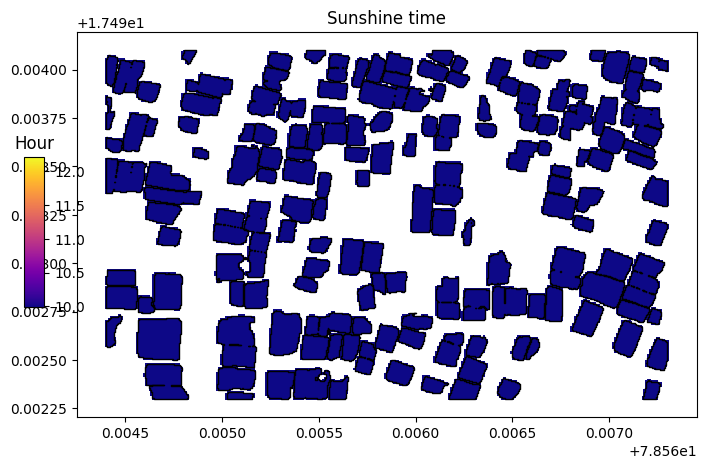

In [ ]:
#calculate sunshine time on the building roof
sunshine = pybdshadow.cal_sunshine(buildings,
                                   day='2022-01-01',
                                   roof=True,
                                   accuracy=1,
                                   precision=900)
#Visualize buildings and sunshine time using matplotlib
import matplotlib.pyplot as plt
fig = plt.figure(1,(10,5))
ax = plt.subplot(111)
#define colorbar
cax = plt.axes([0.15, 0.33, 0.02, 0.3])
plt.title('Hour')
#plot the sunshine time
sunshine.plot(ax = ax,cmap = 'plasma',column ='Hour',alpha = 1,legend = True,cax = cax,)
#Buildings
buildings.plot(ax = ax,edgecolor='k',facecolor=(0,0,0,0))
plt.sca(ax)
plt.title('Sunshine time')
plt.show()

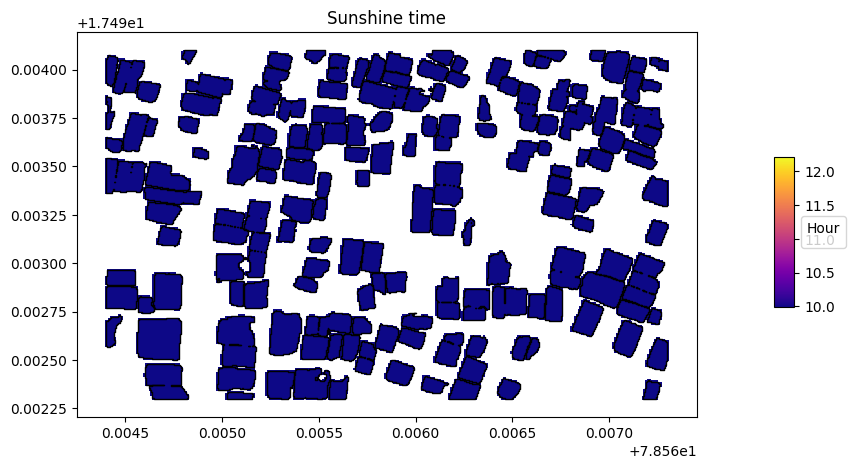

In [ ]:
import matplotlib.pyplot as plt

# Create figure and axis
fig = plt.figure(1, (10, 5))
ax = plt.subplot(111)

# Define colorbar
cax = plt.axes([0.9, 0.33, 0.02, 0.3])  # Adjust the colorbar position to be on the right

# Plot the sunshine time
sunshine.plot(ax=ax, cmap='plasma', column='Hour', alpha=1, legend=True, cax=cax)

# Plot the buildings
buildings.plot(ax=ax, edgecolor='k', facecolor=(0, 0, 0, 0))

# Move the legend to the right using bbox_to_anchor
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Hour")  # Adjust the position

# Set the title
plt.sca(ax)
plt.title('Sunshine time')

# Show the plot
plt.show()

